In [1]:
import pandas as pd
import numpy as np
import sys
import warnings
warnings.filterwarnings('ignore')
from copy import deepcopy,copy
from datetime import datetime
import pickle
import os
import scipy
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
# Import Machine Scientist
from importlib.machinery import SourceFileLoader
# Get the absolute path of the script's directory
script_dir = os.getcwd()
# Define the relative path to the module
relative_module_path = "rguimera-machine-scientist-constrained/machinescientist_ode.py"
path = os.path.join(script_dir, relative_module_path)
ms_ode = SourceFileLoader("ms_ode", path).load_module()


folder_name = 'Train_test_data_lin_term_com2025_03_11-11_21_44'

with open(f'./{folder_name}/x.pkl', 'rb') as file:
    # A new file will be created
    x = pickle.load(file)
with open(f'./{folder_name}/x_test.pkl', 'rb') as file:
    # A new file will be created
    x.update(pickle.load(file))

f_name_train='Full_data_lin_term_prod_2025_03_27-06_00_44/'
active_params=['_a0_','_a2_','_a4_']
#f_name_train='Full_data_lin_term_com_2025_03_27-06_00_27/'
#active_params=['_a0_','_a1_','_a3_','_a6_']
try:
    file = open(f'./{f_name_train}/mdl_refit_train1.pkl','rb')
    file = open(f'./mdl_mod_model2_train.pkl','rb')
except:
    pass
print(file)
bms_fulldata = pickle.load(file)
print(bms_fulldata)
print(bms_fulldata.E)

parameter_dict=deepcopy(bms_fulldata.par_values)


try:
    file = open(f'./{f_name_train}/mdl_refit_test1.pkl','rb')
    file = open(f'./mdl_mod_model2_test.pkl','rb')
except:
    pass
print(file)
bms_fulldata_test = pickle.load(file)

parameter_dict.update(deepcopy(bms_fulldata_test.par_values))



<_io.BufferedReader name='./mdl_mod_model2_train.pkl'>
((_a0_ * B) - (((exp((B * _a2_)) * (_a4_ * B)) ** (B ** 3)) * (_a0_ * B)))
-14846.7216959914
<_io.BufferedReader name='./mdl_mod_model2_test.pkl'>


In [2]:

rows = []
for dataset, params in parameter_dict.items():
    a0 = params.get("_a0_")
    a2 = params.get("_a2_")
    a4 = params.get("_a4_")

    row = {
        "Dataset": dataset,
        "r": a0,
        "c0": a4,
        "c1":a2,
    }
    rows.append(row)

# Save to CSV
df = pd.DataFrame(rows)
display(df)
df.to_csv("model_parameters.csv", index=False)

,Dataset,r,c0,c1
0,B5,33.413286,4.344873,-1.599515
1,A8,28.346295,5.462349,-2.016661
2,G7,66.377809,4.112558,-1.513042
3,A9,34.930560,5.298242,-1.952555
4,F7,39.920338,4.468268,-1.644525
...,...,...,...,...
164,R.S.19 D-Glucose_19,7.976605,2.804185,-1.024495
165,R.S.19 Guanidine_19,1.095914,0.005790,12.006303
166,R.S.19 Cytidine_19,5.169755,2.380873,-0.870462
167,R.S.19 Nitrogen Neg. Control_19,20.822195,4.551090,-1.661511


In [3]:
import matplotlib.gridspec as gridspec
from scipy.stats import pearsonr, spearmanr
fig = plt.figure(figsize=(12, 9))
gs = gridspec.GridSpec(3, 4, figure=fig,wspace=0.1,hspace=0.1)

<Figure size 1200x900 with 0 Axes>

# Correlation with max growth rate
Here I take the growth rate as the maximum numerical derivative

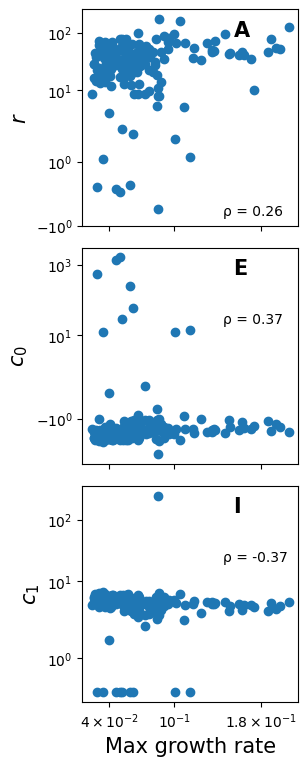

<Figure size 640x480 with 0 Axes>

In [4]:
# (Max) growth rate
# I will approximate the growth rate as the maximum derivative

m_growth_rate={}
for col in list(x.keys()):
    m_growth_rate[col]=max(x[col].dx.to_numpy())


# Plotting the empirical growth rate vs model parameters
c=0
for param in active_params:
    model_param={col:value[param] for col,value in parameter_dict.items()}
    keys = list(x.keys())
    values1 = [model_param[k] for k in keys]
    values2 = [m_growth_rate[k] for k in keys]
    ax = fig.add_subplot(gs[c, 0])
    
    ax.scatter(values2,values1,label=param[1:-1])
    rho, p = spearmanr(values2, values1)
    chars='AEI'
    ax.text(0.7, 0.95, chars[c], transform=ax.transAxes, ha="left", va="top", fontsize=15, weight='bold')
    # Add correlation text inside plot
    ax.text(0.65, 0.1 if c==0 else 0.7, f"ρ = {rho:.2f}", 
            transform=ax.transAxes, 
            ha="left", va="top", fontsize=10,
            bbox=dict(facecolor="white", alpha=1, edgecolor="none"))
    ax.set_xscale('symlog')
    ax.set_yscale('symlog')
    ax.set_box_aspect(1)
    if c==0:
        ax.set_ylabel(r'$r$',fontsize=15)
    if c==1:
        ax.set_ylabel(r'$c_0$',fontsize=15)
    if c==2:
        ax.set_ylabel(r'$c_1$',fontsize=15)
    ax.set_yticks([])
    if c==0:
        ax.set_yticks([-1,1,10,100])
    if c==1:
        ax.set_yticks([-1,10,1000])
    if c==2:
        ax.set_yticks([1,10,100])
    ax.tick_params(which='minor', bottom=False, left=False)
    #plt.xlim(-1e2,1e2)
    ax.set_xticks([])
    ax.set_xticks([4e-2,1e-1,1.8e-1])
    if c<2:
        ax.set_xticklabels([])
    c+=1
ax.set_xlabel('Max growth rate',fontsize=15)
plt.draw()
display(fig)

# Growth rate as the slope of the curve
Here I fit a linear model with the values around the maximum growth rate (numerical deriv).
The growth rate will be the slope.

In [5]:
growth_rate_lm={}

for col in list(x.keys()):
    threshold = 0.75 * m_growth_rate[col]  # adjust as needed
    window_size = 3
    #
    df=x[col]
    indices_above_threshold = np.where(np.abs(df['dx']) >= threshold)[0]
    
    start_idx = indices_above_threshold[0]
    end_idx = indices_above_threshold[-1]
    window_df = df.iloc[start_idx:end_idx + 1]
    
    #Growth slope
    model = LinearRegression()
    model.fit(window_df.t.to_numpy().reshape(-1, 1), window_df.B.to_numpy())
    # Slope of the plateau
    growth_rate_lm[col] = model.coef_[0]
    """
    plt.plot(x[col].t,x[col].B)
    plt.plot(window_df.t, model.predict(window_df.t.to_numpy().reshape(-1, 1)))
    plt.show()
    """

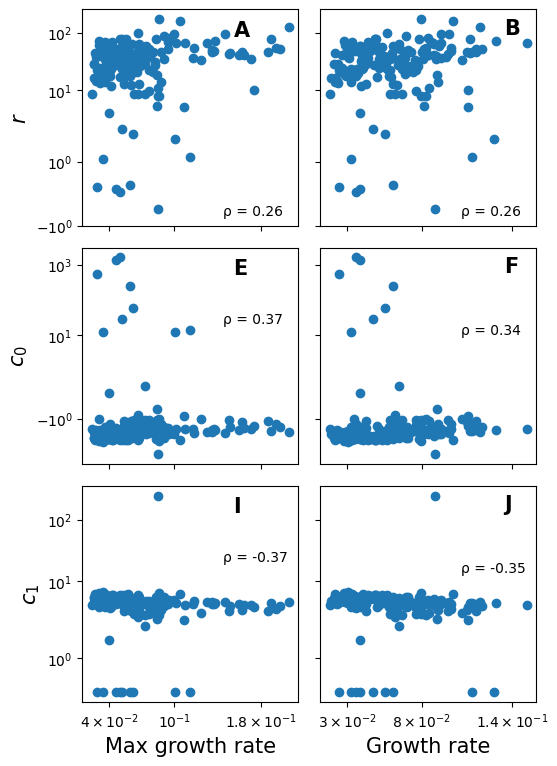

<Figure size 640x480 with 0 Axes>

In [6]:
# Plotting the empirical growth rate vs model parameters
c=0
for param in active_params:
    model_param={col:value[param] for col,value in parameter_dict.items()}
    keys = list(x.keys())
    values1 = [model_param[k] for k in keys]
    values2 = [growth_rate_lm[k] for k in keys]
    ax = fig.add_subplot(gs[c, 1])
    
    ax.scatter(values2,values1,label=param[1:-1])
    chars='BFJ'
    ax.text(0.85, 0.96, chars[c], transform=ax.transAxes, ha="left", va="top", fontsize=15, weight='bold')
    rho, p = spearmanr(values2, values1)
    ax.text(0.65, 0.1 if c==0 else 0.65, f"ρ = {rho:.2f}", 
            transform=ax.transAxes, 
            ha="left", va="top", fontsize=10,
            bbox=dict(facecolor="white", alpha=1, edgecolor="none"))
    ax.set_xscale('symlog')
    ax.set_yscale('symlog')
    ax.set_box_aspect(1)
    ax.set_yticks([])
    if c==0:
        ax.set_yticks([-1,1,10,100])
    if c==1:
        ax.set_yticks([-1,10,1000])
    if c==2:
        ax.set_yticks([1,10,100])
    ax.tick_params(which='minor', bottom=False, left=False)
    ax.set_xticks([])
    ax.set_xticks([3e-2,8e-2,1.4e-1])
    if c<2: ax.set_xticklabels([])
    ax.set_yticklabels([])
    c+=1
    #plt.xlim(-1e2,1e2)
ax.set_xlabel('Growth rate',fontsize=15)
plt.draw()
display(fig)

# Correlation for the carrying capacity
Fist I plot the carrying capacity guess.
I compute a guess of the start plateau time(t_ini_k)-when the derivative roughly goes near zero for more than 3 points stright.
Then the carrying capacity is the mean from t_ini_k to end.

Also, I compute the slope of the stationaty regime with a linear model.

In [7]:
# Correlation with carrying capacity
# I will approximate the carrying capacity as the average when derviative goes to zero

k_estimated={}
k_slope_estimated={}
for col in list(x.keys()):
    threshold = m_growth_rate[col]/10.  # adjust as needed
    window_size = 3
    #
    
    max_deriv_idx = x[col]['dx'].idxmax()
    after_peak = x[col].loc[max_deriv_idx:]
    #plateau_start = after_peak.index[np.abs(after_peak['dx']) < threshold][0]
    
    low_deriv = np.abs(after_peak['dx']) < threshold
    rolling_low = low_deriv.rolling(window=window_size).sum()
    plateau_start_idx = rolling_low[rolling_low == window_size].index.min()
    try:
        #Plaeau slope
        model = LinearRegression()
        model.fit(after_peak.loc[plateau_start_idx:, 't'].to_numpy().reshape(-1, 1), after_peak.loc[plateau_start_idx:, 'B'].to_numpy())
        # Slope of the plateau
        k_slope_estimated[col] = model.coef_[0]
        #plt.plot(x[col].loc[plateau_start_idx:].t, model.predict(x[col].loc[plateau_start_idx:].t.to_numpy().reshape(-1, 1)))
    except:
        pass
    #
    if pd.notna(plateau_start_idx):
        k_estimated[col] = after_peak.loc[plateau_start_idx:, 'B'].mean()
        print('t plateau start',x[col].loc[plateau_start_idx].t,k_estimated[col])
        """
        plt.plot(x[col].t,x[col].B)
        plt.vlines(x[col].loc[plateau_start_idx].t, min(x[col].B), max(x[col].B))
        plt.hlines(k_estimated[col],0,30)
        plt.show()
        """

t plateau start 21.163379999999986 0.6428339473684211
t plateau start 10.077800000000002 0.6666929756097562
t plateau start 16.124480000000002 0.625419379310345
t plateau start 16.62837 0.5198452142857143
t plateau start 12.597250000000003 0.697309638888889
t plateau start 18.643929999999994 0.4400089583333333
t plateau start 25.69838999999997 0.6402968
t plateau start 17.636149999999997 0.6447270384615386
t plateau start 22.171159999999983 0.7554448235294118
t plateau start 11.589470000000002 0.497501947368421
t plateau start 19.147819999999992 0.5574887391304348
t plateau start 12.597250000000003 0.6071801666666666
t plateau start 8.5 0.6396916279069768
t plateau start 10.5 0.5303612307692308
t plateau start 20.5 0.7071364736842105
t plateau start 20.5 0.5531732631578947
t plateau start 13.5 0.6025905757575758
t plateau start 17.0 0.5443466153846154
t plateau start 12.5 0.5975560571428572
t plateau start 9.5 0.4127845609756098
t plateau start 20.5 0.9134725263157895
t plateau start 2

# Correlation of the carrying capacity

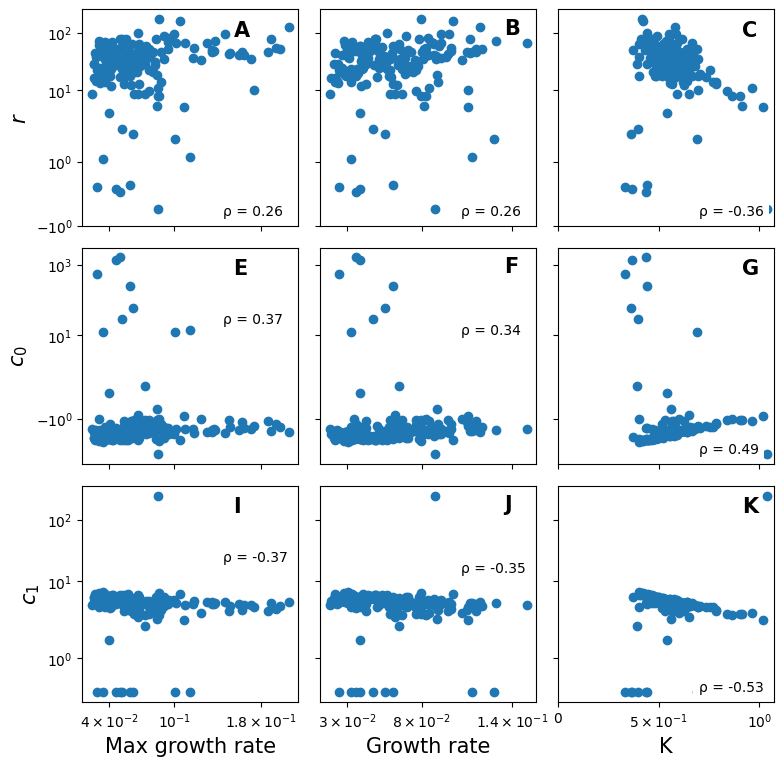

<Figure size 640x480 with 0 Axes>

In [8]:
# Correlation plots
# Plotting the empirical growth rate vs model parameters
c=0
for param in active_params:
    model_param={col:value[param] for col,value in parameter_dict.items()}
    keys = list(k_estimated.keys())
    values1 = [model_param[k] for k in keys]
    values2 = [k_estimated[k] for k in keys]
    ax = fig.add_subplot(gs[c, 2])
    ax.scatter(values2,values1,label=param[1:-1])
    chars='CGK'
    ax.text(0.85, 0.95, chars[c], transform=ax.transAxes, ha="left", va="top", fontsize=15, weight='bold')
    rho, p = spearmanr(values2, values1)
    ax.text(0.65, 0.1 if c==0 else 0.1, f"ρ = {rho:.2f}", 
            transform=ax.transAxes, 
            ha="left", va="top", fontsize=10,
            bbox=dict(facecolor="white", alpha=1, edgecolor="none"))
    ax.set_xscale('symlog')
    ax.set_yscale('symlog')
    ax.set_box_aspect(1)
    ax.set_yticks([])
    if c==0:
        ax.set_yticks([-1,1,10,100])
    if c==1:
        ax.set_yticks([-1,10,1000])
    if c==2:
        ax.set_yticks([1,10,100])
    ax.tick_params(which='minor', bottom=False, left=False)
    ax.set_xticks([])
    ax.set_xticks([0,0.5,1])
    if c<2: ax.set_xticklabels([])
    ax.set_yticklabels([])
    c+=1
ax.set_xlabel('K',fontsize=15)
plt.draw()
display(fig)

# Correlation of the stationary slope

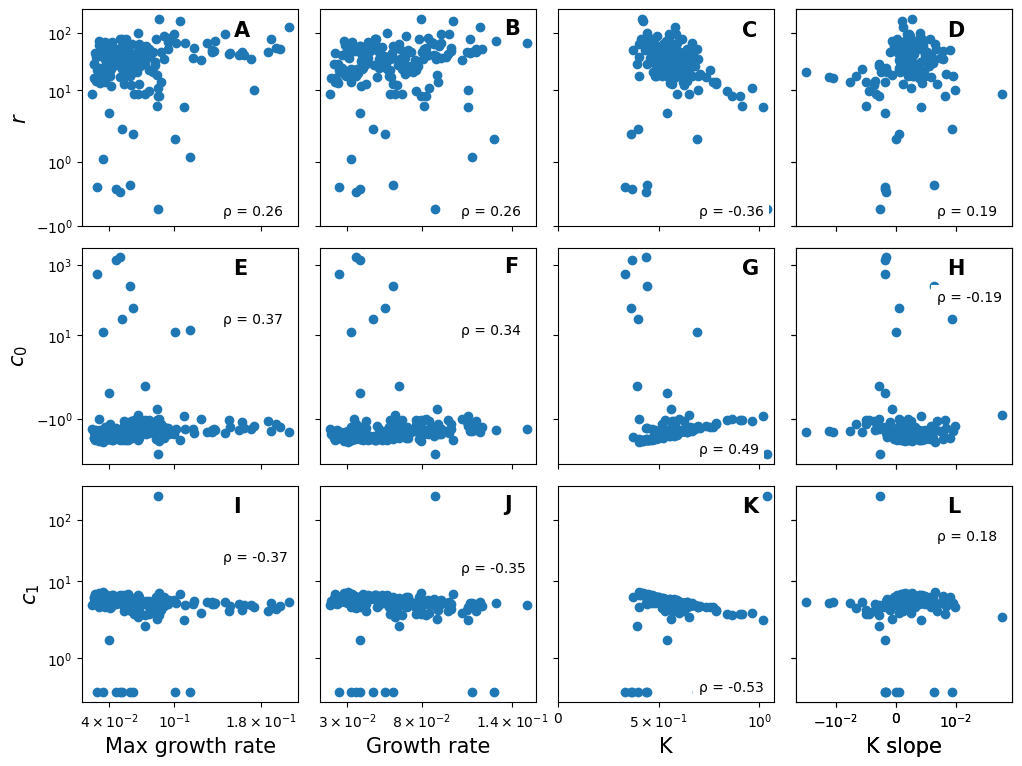

<Figure size 640x480 with 0 Axes>

In [10]:
# Slope of the stationary phase
c=0
for param in active_params:
    model_param={col:value[param] for col,value in parameter_dict.items()}
    keys = list(k_slope_estimated.keys())
    values1 = [model_param[k] for k in keys]
    values2 = [k_slope_estimated[k] for k in keys]
    ax = fig.add_subplot(gs[c, 3])
    
    ax.scatter(values2,values1,label=param[1:-1])
    chars='DHL'
    ax.text(0.7, 0.95, chars[c], transform=ax.transAxes, ha="left", va="top", fontsize=15, weight='bold')
    rho, p = spearmanr(values2, values1)
    ax.text(0.65, 0.1 if c==0 else 0.8, f"ρ = {rho:.2f}", 
            transform=ax.transAxes, 
            ha="left", va="top", fontsize=10,
            bbox=dict(facecolor="white", alpha=1, edgecolor="none"))
    ax.set_xscale('symlog')
    ax.set_yscale('symlog')
    ax.set_box_aspect(1)
    ax.set_yticks([])
    if c==0:
        ax.set_yticks([-1,1,10,100])
    if c==1:
        ax.set_yticks([-1,10,1000])
    if c==2:
        ax.set_yticks([1,10,100])
    ax.tick_params(which='minor', bottom=False, left=False)
    ax.set_xticks([])
    ax.set_xticks([-1e-2,0,1e-2])
    if c<2: ax.set_xticklabels([])
    ax.set_yticklabels([])
    c+=1
ax.set_xlabel('K slope',fontsize=15)

plt.tight_layout()

plt.draw()
fig.savefig('/export/home/oriolca/ThesisPlots/Bacteria_param_corr.pdf',dpi=300,format='pdf', bbox_inches='tight')
display(fig)
plt.show()